In [69]:
# load module
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger


from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

#import tensorflow as tf 
import tensorboard as tb 
#tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'
#plt.rcParams['font.sans-serif'] = ['NanumGothic.ttf', 'sans-serif']


def moving_average_alpha(df: pd.DataFrame, unit: float):
    '''
    training datset에 ewma를 적용하는 함수 , unit = 0.3 or 0.4
    '''
    ret_df = pd.DataFrame()
    max_value = df['count'].max()
    # forward df
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        inv_dong_df = df[df['h_dong'] == dong][::-1]
        dong_df['count'] = dong_df['count'].ewm(alpha = unit).mean()
        #for_ewma = dong_df['count'].ewm(alpha = unit).mean()
        back_ewma = inv_dong_df['count'].ewm(alpha = unit).mean()

        #ewma = (for_ewma + back_ewma)/2 
        df['count'][dong_df.index] = back_ewma 
    df['count'] = df['count']  /  df['count'].max() * (max_value)
    
    #print(max_value , df['count'].max())
    return df

def moving_average_com(df: pd.DataFrame, unit: float):
    '''
    training datset에 ewma를 적용하는 함수 , unit = 0.3 or 0.4
    '''
    ret_df = pd.DataFrame()
    max_value = df['count'].max()
    # forward df
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        inv_dong_df = df[df['h_dong'] == dong][::-1]
        dong_df['count'] = dong_df['count'].ewm(com = unit).mean()
        #for_ewma = dong_df['count'].ewm(alpha = unit).mean()
        back_ewma = inv_dong_df['count'].ewm(com = unit).mean()

        #ewma = (for_ewma + back_ewma)/2 
        df['count'][dong_df.index] = back_ewma 
    df['count'] = df['count']  /  df['count'].max() * (max_value)
    
    #print(max_value , df['count'].max())
    return df
def moving_average_span(df: pd.DataFrame, unit: float):
    '''
    training datset에 ewma를 적용하는 함수 , unit = 0.3 or 0.4
    '''
    ret_df = pd.DataFrame()
    max_value = df['count'].max()
    # forward df
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        inv_dong_df = df[df['h_dong'] == dong][::-1]
        dong_df['count'] = dong_df['count'].ewm(span = unit).mean()
        #for_ewma = dong_df['count'].ewm(alpha = unit).mean()
        back_ewma = inv_dong_df['count'].ewm(span = unit).mean()

        #ewma = (for_ewma + back_ewma)/2 
        df['count'][dong_df.index] = back_ewma 
    df['count'] = df['count']  /  df['count'].max() * (max_value)
    
    #print(max_value , df['count'].max())
    return df

def moving_average_halflife(df: pd.DataFrame, unit: float):
    '''
    training datset에 ewma를 적용하는 함수 , unit = 0.3 or 0.4
    '''
    ret_df = pd.DataFrame()
    max_value = df['count'].max()
    # forward df
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        inv_dong_df = df[df['h_dong'] == dong][::-1]
        dong_df['count'] = dong_df['count'].ewm(halflife = unit).mean()
        #for_ewma = dong_df['count'].ewm(alpha = unit).mean()
        back_ewma = inv_dong_df['count'].ewm(halflife = unit).mean()

        #ewma = (for_ewma + back_ewma)/2 
        df['count'][dong_df.index] = back_ewma 
    df['count'] = df['count']  /  df['count'].max() * (max_value)
    
    #print(max_value , df['count'].max())
    return df



def data_processing(path : str  , unit : float , ewma_fun : moving_average_alpha ):
    # path  : 데이터가 저장된 경로
    # unit  : ewma의 unit
    
    data = pd.read_csv(path)    
    # 사용하는 column만 선택
    data = data[['REG_DTIME', 'h_dong', 'count', 'pops', 'windspd','humid', 'temp', 'precip_form', 'precip', 'isHoliday']]
    data['REG_DTIME'] = pd.to_datetime(data['REG_DTIME'])
    data['DOW'] = data['REG_DTIME'].dt.dayofweek
    data['HOD'] = data['REG_DTIME'].dt.hour
    data['MOY'] = data['REG_DTIME'].dt.month
    # time_idx 시간을 고유하게 표현(윤년)
    #for x , y in enumerate(data['REG_DTIME'].unique()):
    #    t_data_index = data[data['REG_DTIME'] == y].index
    #    data.loc[t_data_index , 'time_idx'] = x
    data["time_idx"] =  \
    data["REG_DTIME"].dt.year * 365*24 + \
    data["REG_DTIME"].dt.day_of_year * 24  + \
    data["REG_DTIME"].dt.hour 
    data["time_idx"] -= data["time_idx"].min()
    # trainer에 넣기 위해서 category로 만들기
    data['h_dong'] = data['h_dong'].astype(str)
    data['DOW'] = data['DOW'].astype(str)
    data['HOD'] = data['HOD'].astype(str)
    data['MOY'] = data['MOY'].astype(str)
    data['precip_form'] = data['precip_form'].astype(str)
    data['isHoliday'] = data['isHoliday'].astype(str)
    # ewma 적용
    if unit == 0:
        return data
    else:
        data = ewma_fun(data,unit)
        return data

In [70]:
data_processing('../../test.csv' , 4 ,moving_average_halflife)

,REG_DTIME,h_dong,count,pops,windspd,humid,temp,precip_form,precip,isHoliday,DOW,HOD,MOY,time_idx
0,2022-01-01 00:00:00,석사동,0.000000e+00,34593.0,1.4,60.0,-9.7,0.0,0.0,True,5,0,1,0
1,2022-01-01 00:00:00,신동면,0.000000e+00,2602.0,0.3,48.0,-8.6,0.0,0.0,True,5,0,1,0
2,2022-01-01 00:00:00,강남동,0.000000e+00,22607.0,1.4,60.0,-9.7,0.0,0.0,True,5,0,1,0
3,2022-01-01 00:00:00,서 면,0.000000e+00,3782.0,1.4,60.0,-9.7,0.0,0.0,True,5,0,1,0
4,2022-01-01 00:00:00,남 면,0.000000e+00,1073.0,0.3,48.0,-8.6,0.0,0.0,True,5,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29227,2022-02-27 23:00:00,퇴계동,3.188176e-01,48681.0,0.7,80.0,0.8,0.0,0.0,False,6,23,2,1391
29228,2022-02-27 23:00:00,북산면,5.268275e-22,965.0,0.0,84.0,2.6,0.0,0.0,False,6,23,2,1391
29229,2022-02-27 23:00:00,조운동,3.526921e-07,2675.0,0.7,80.0,0.8,0.0,0.0,False,6,23,2,1391
29230,2022-02-27 23:00:00,동산면,6.688150e-07,1445.0,0.5,89.0,1.6,0.0,0.0,False,6,23,2,1391


In [81]:
def veiw_ewma(f_path : str, unit : float , dong : str , funs : moving_average_halflife):
    data = data_processing(f_path, unit , funs)
    dong_data = data[data['h_dong'] ==dong]
    dong_data.reset_index(inplace=True)
    plt.figure(figsize = (18, 4))
    plt.plot(dong_data['count'])
    plt.title(f'test data ,  dong : {dong} , unit : {unit} , ewma_method : {funs}')
    

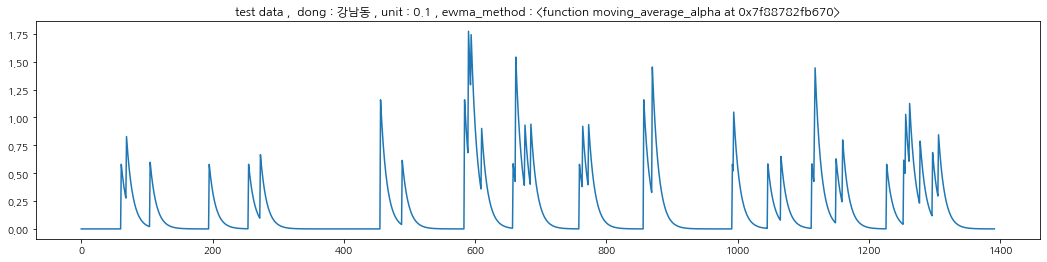

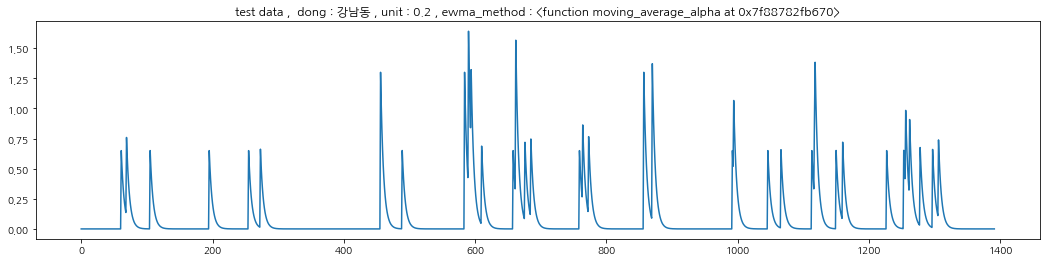

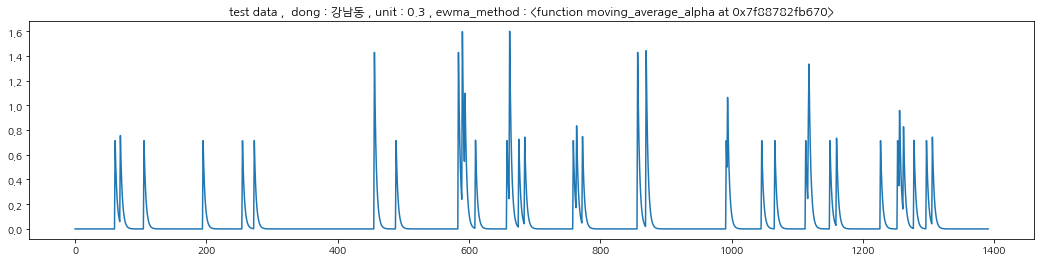

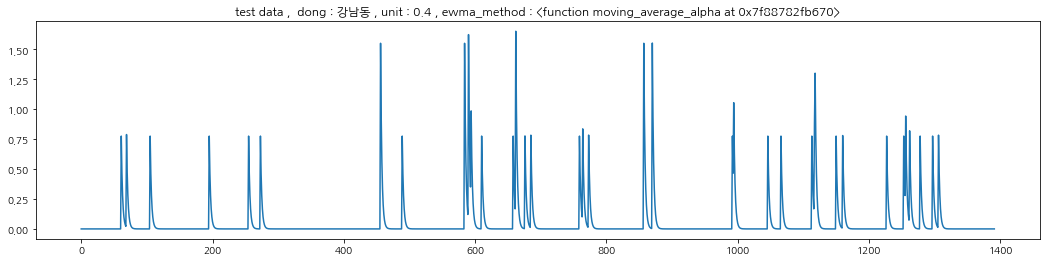

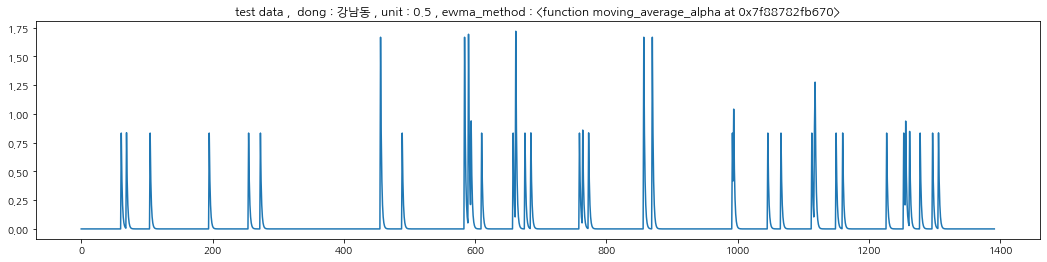

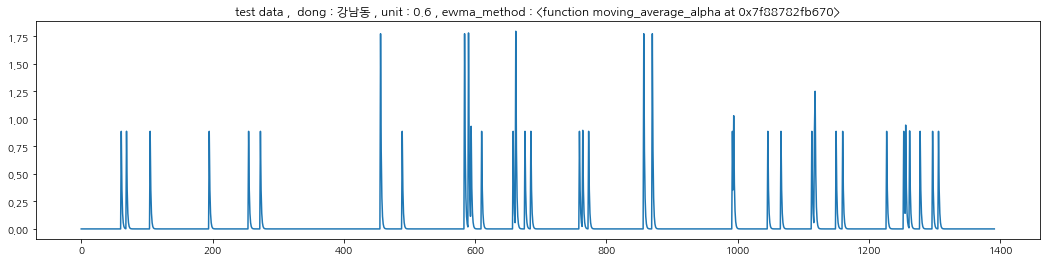

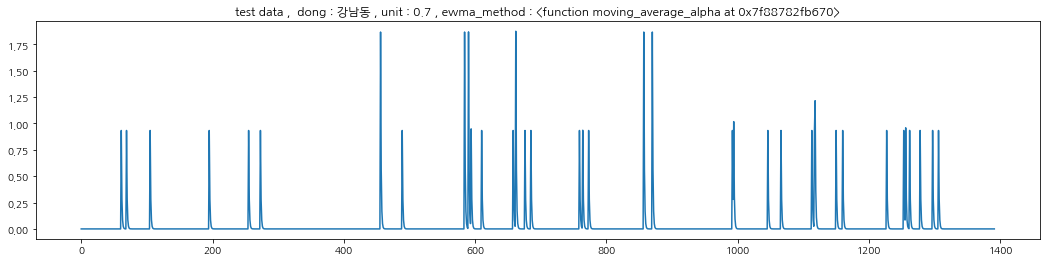

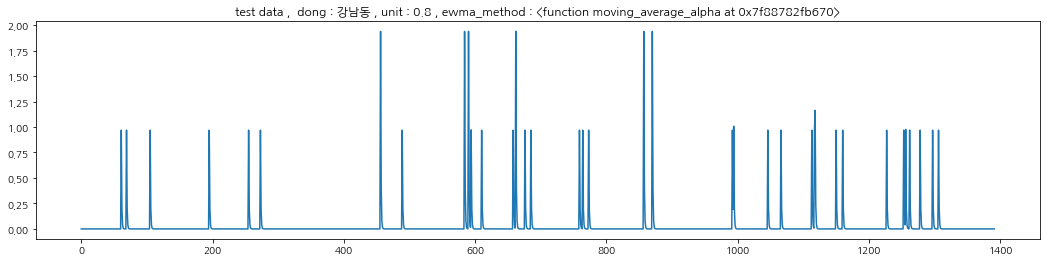

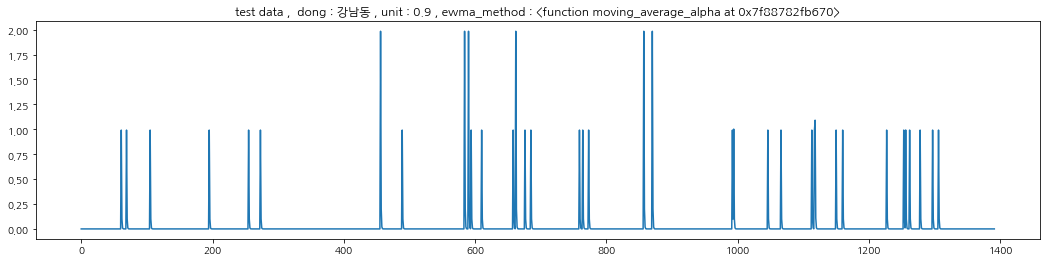

In [82]:
   for unit in np.arange(1,10)/10:
    veiw_ewma('../../test.csv' , unit ,'강남동' , moving_average_alpha)

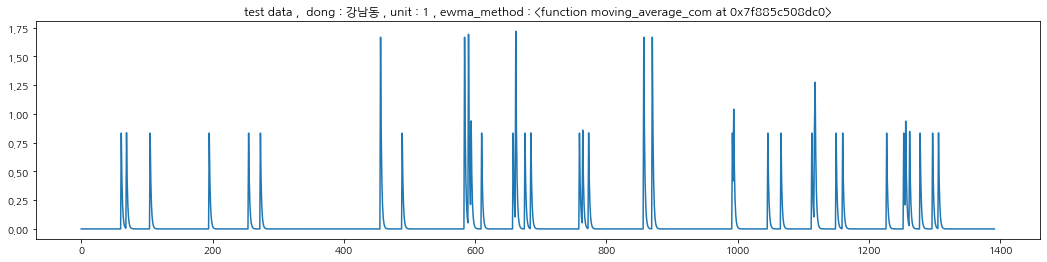

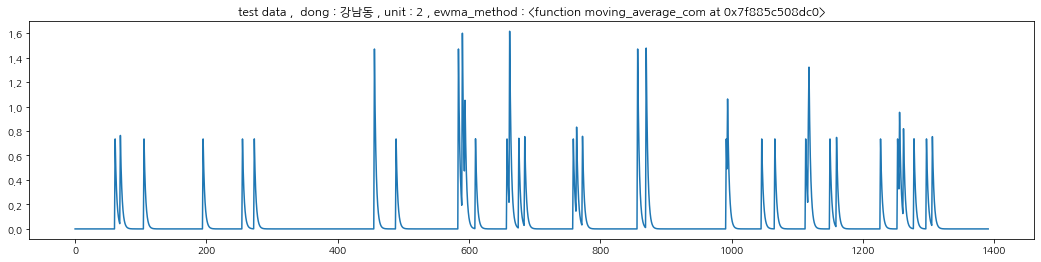

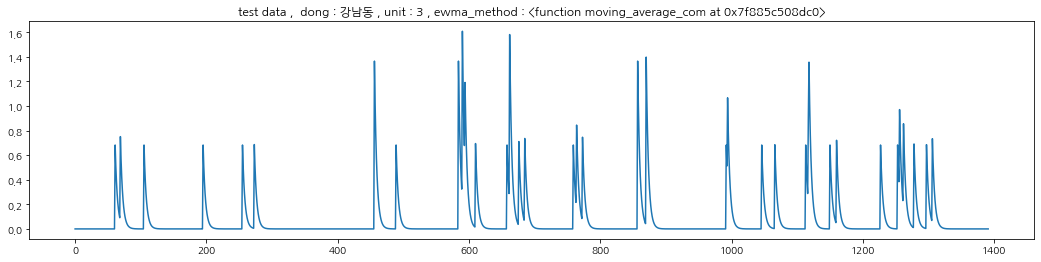

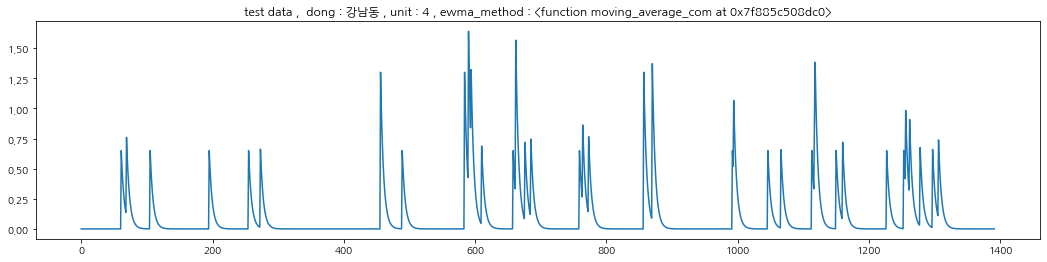

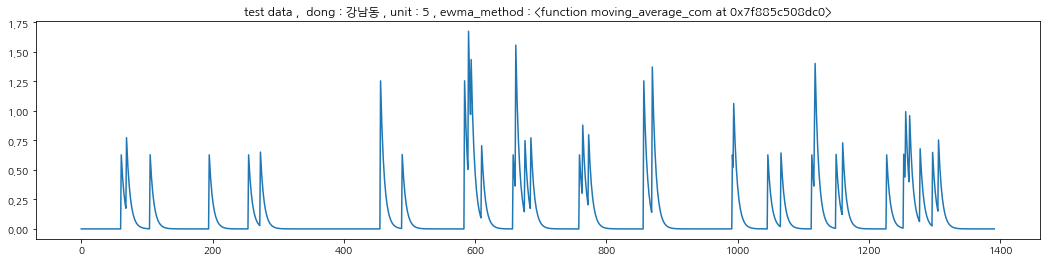

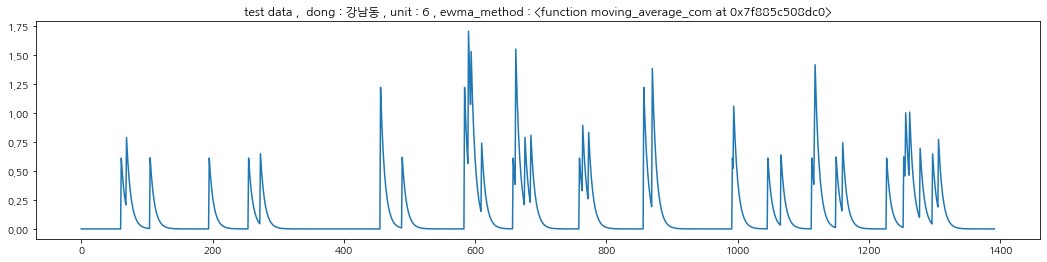

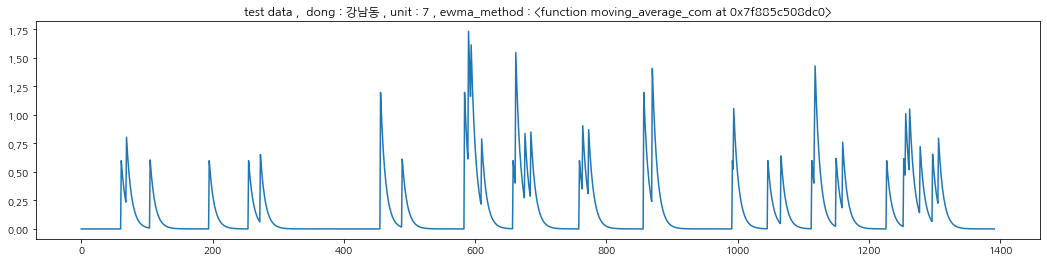

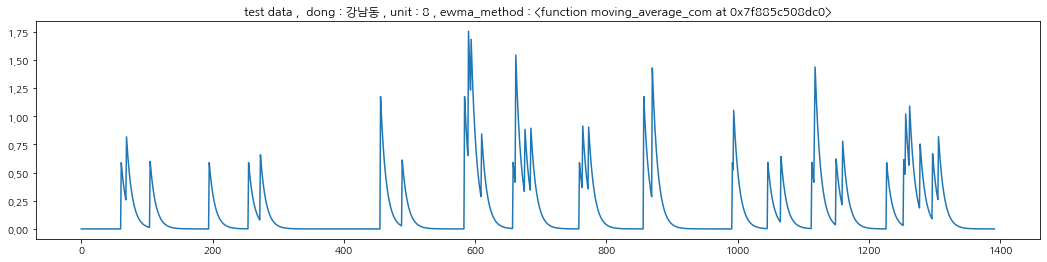

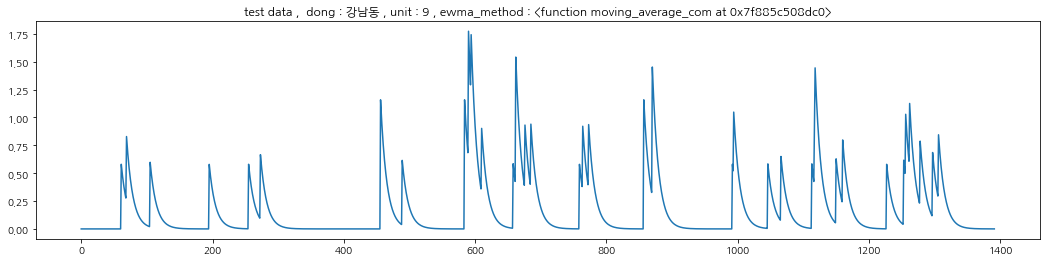

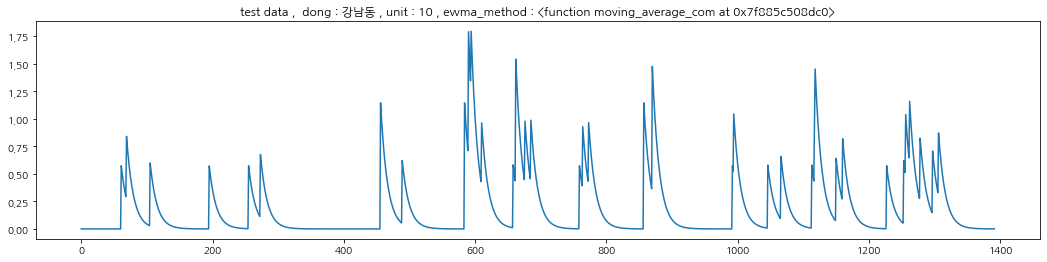

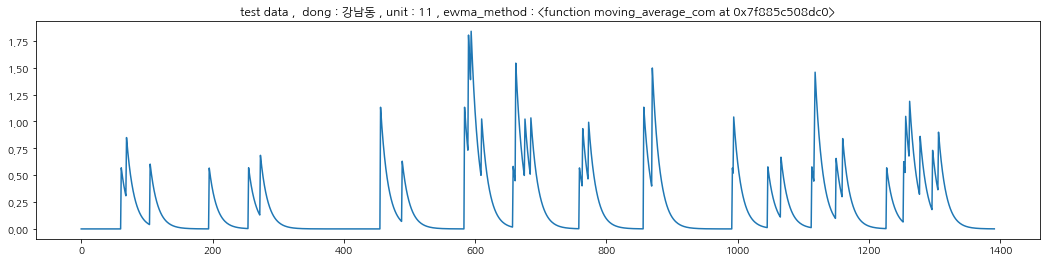

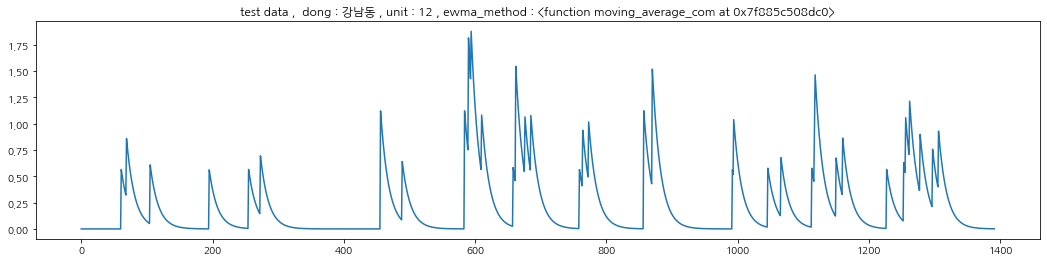

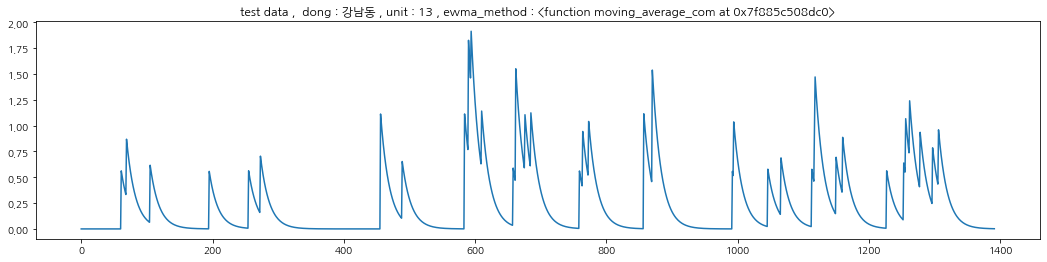

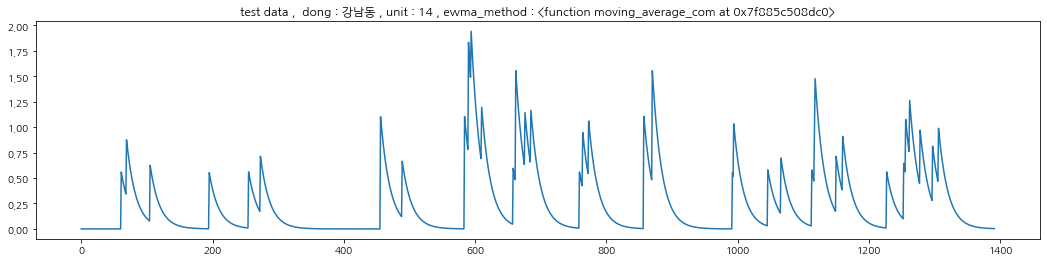

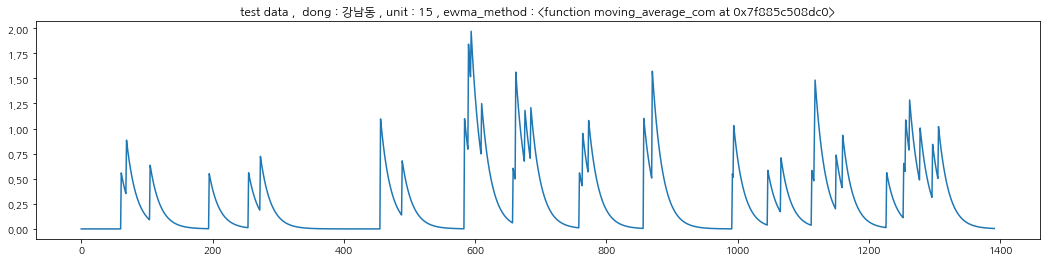

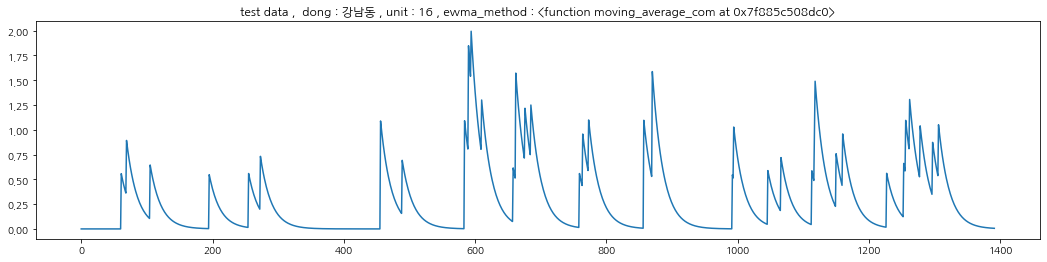

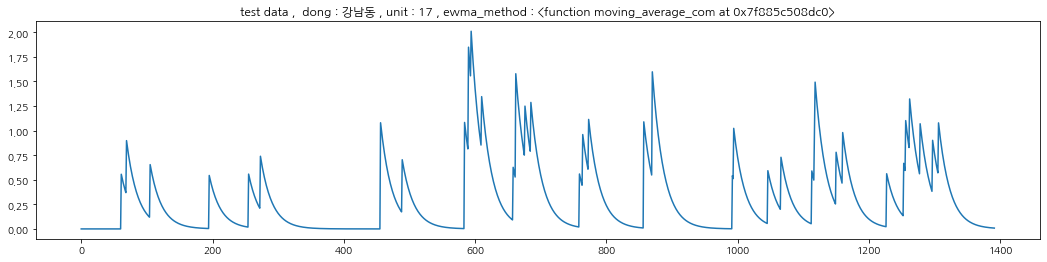

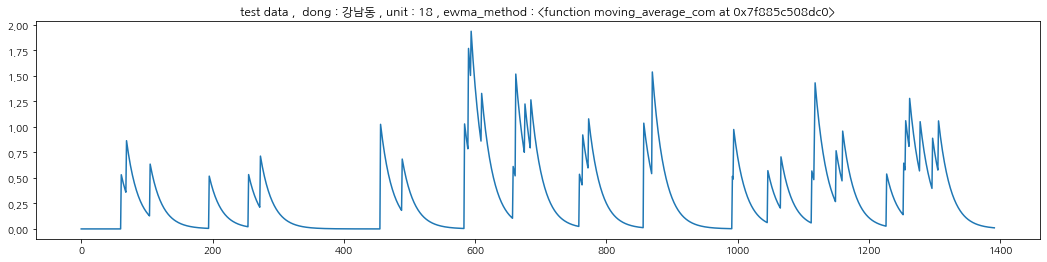

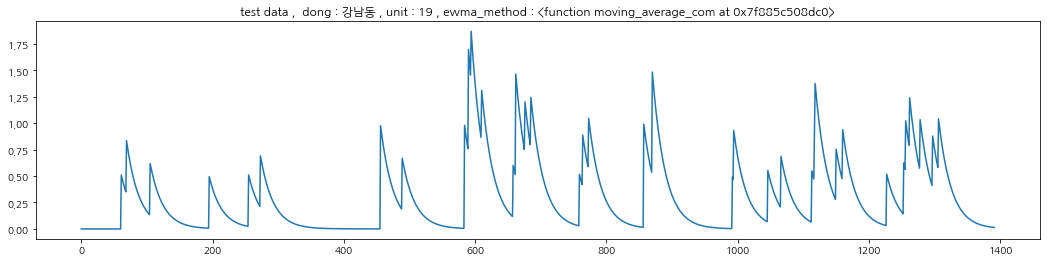

In [83]:
for unit in np.arange(1,20) :
    veiw_ewma('../../test.csv' , unit ,'강남동' , moving_average_com)

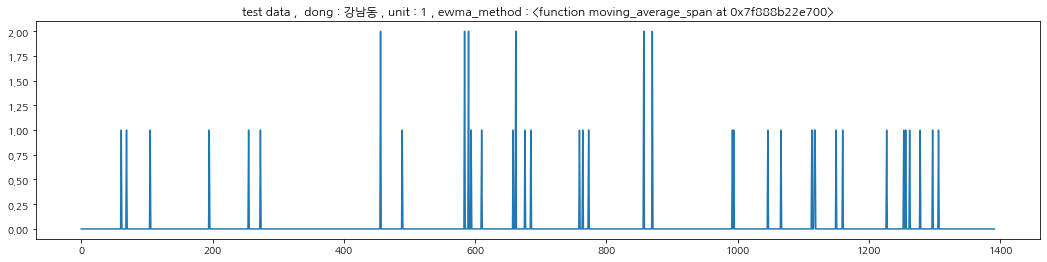

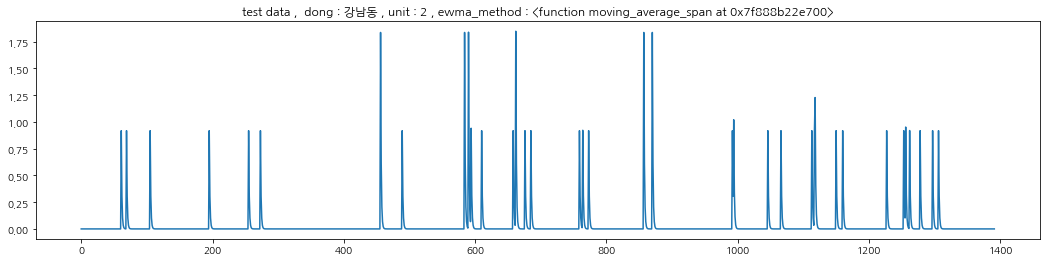

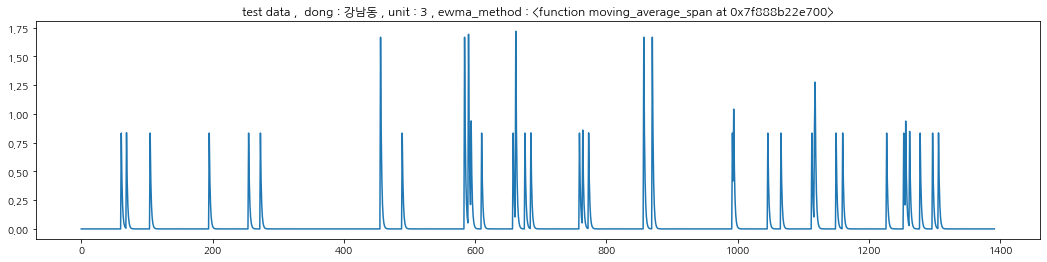

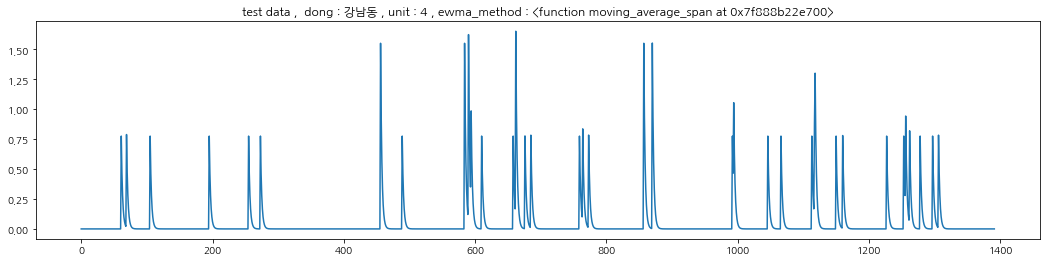

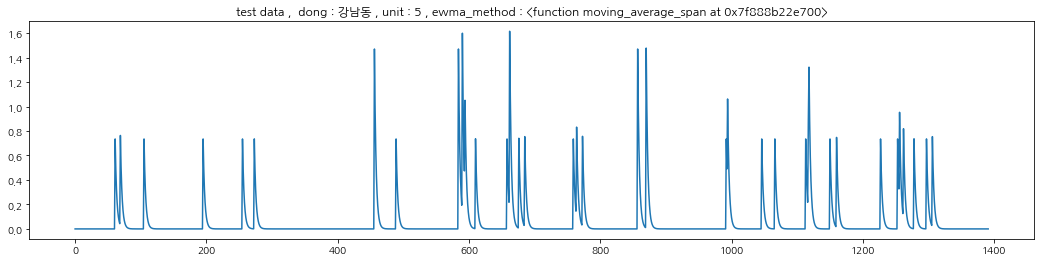

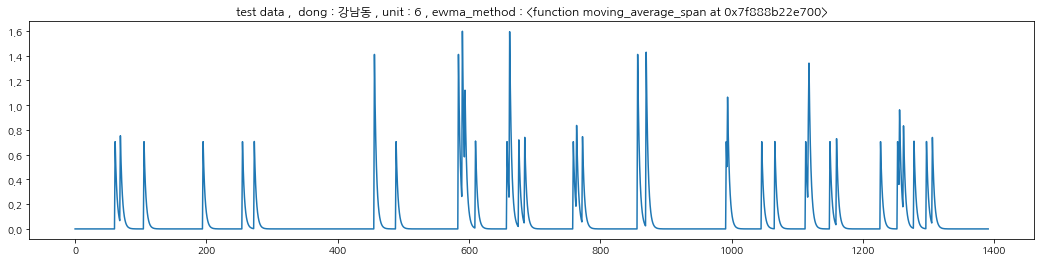

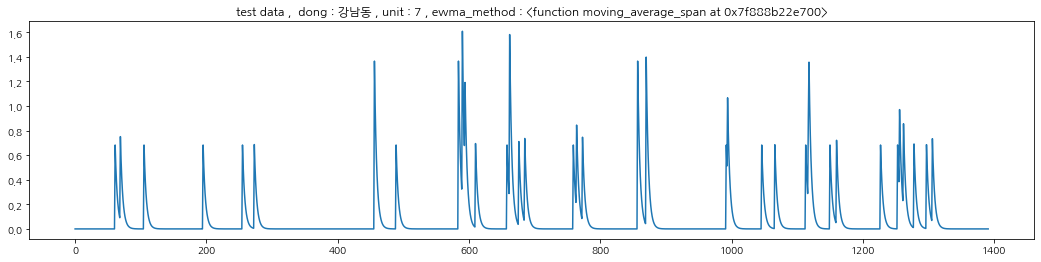

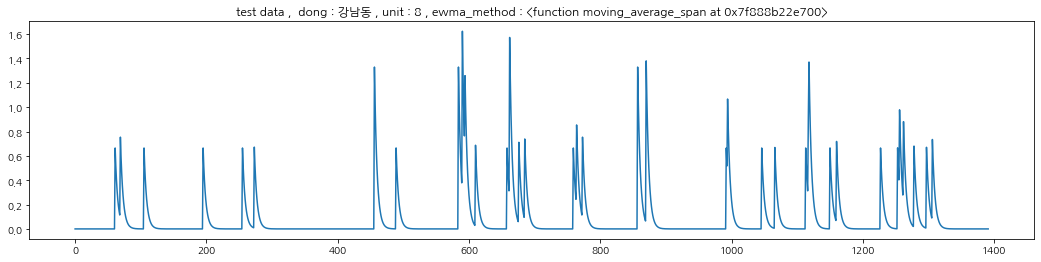

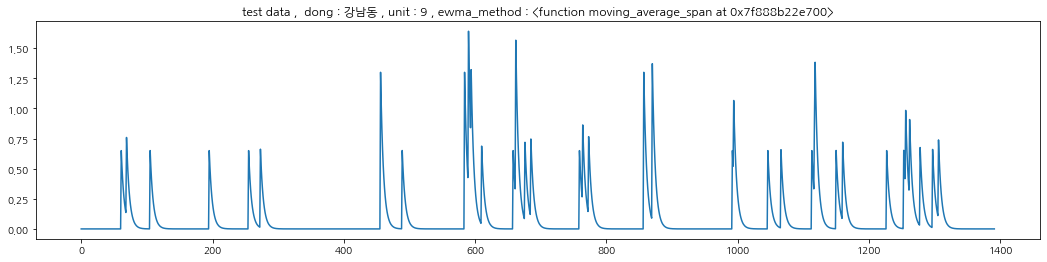

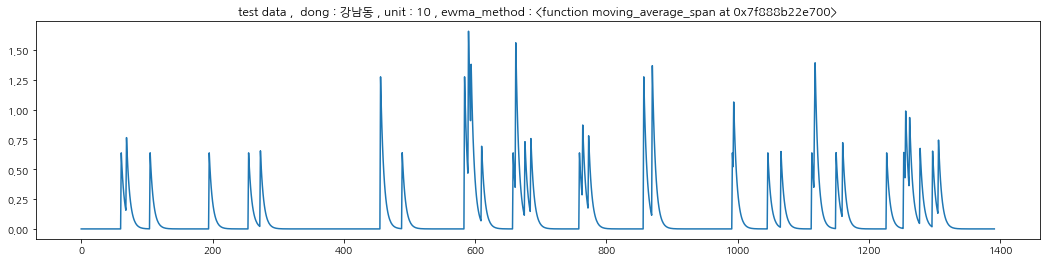

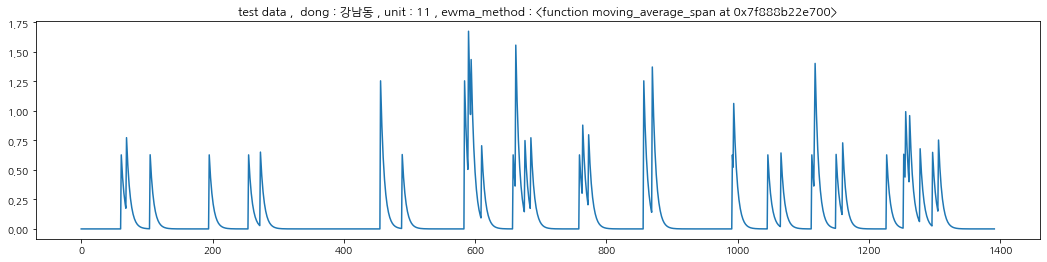

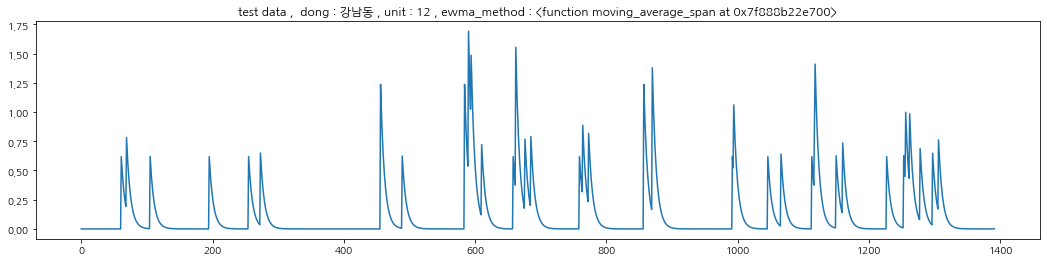

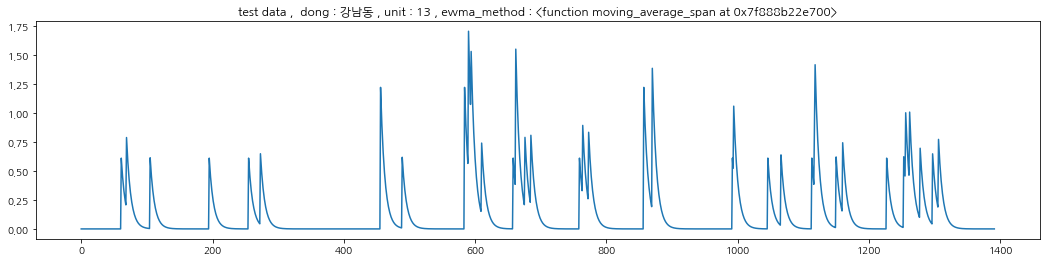

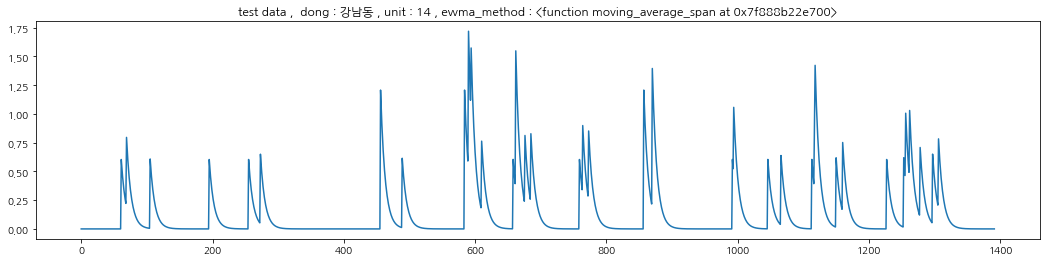

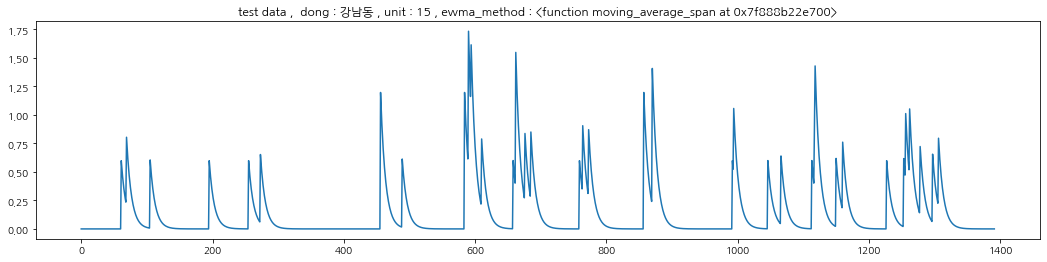

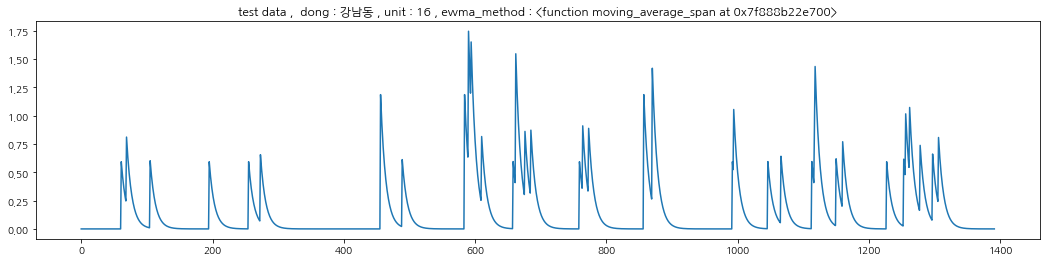

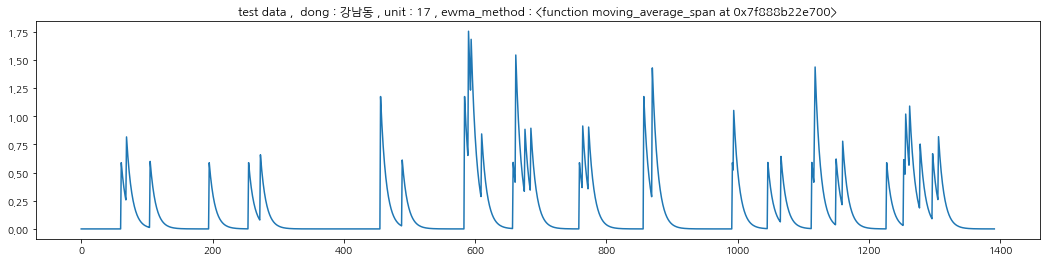

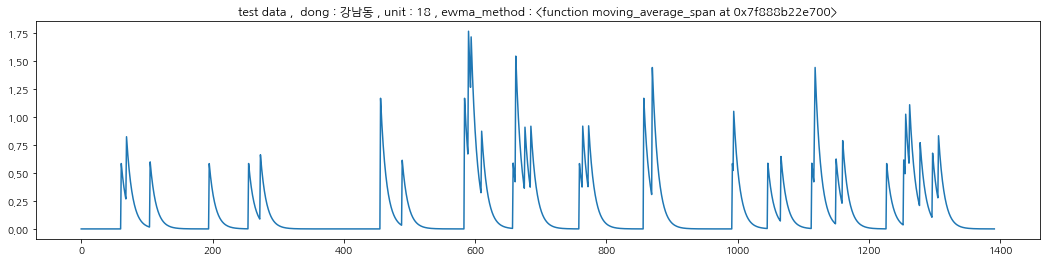

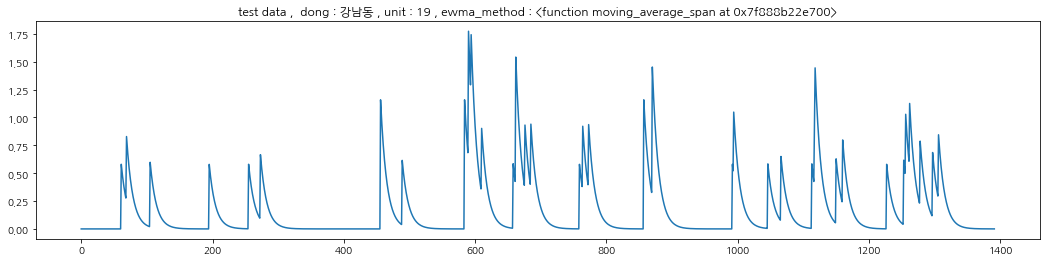

In [84]:
for unit in np.arange(1,20) :
    veiw_ewma('../../test.csv' , unit ,'강남동' , moving_average_span)

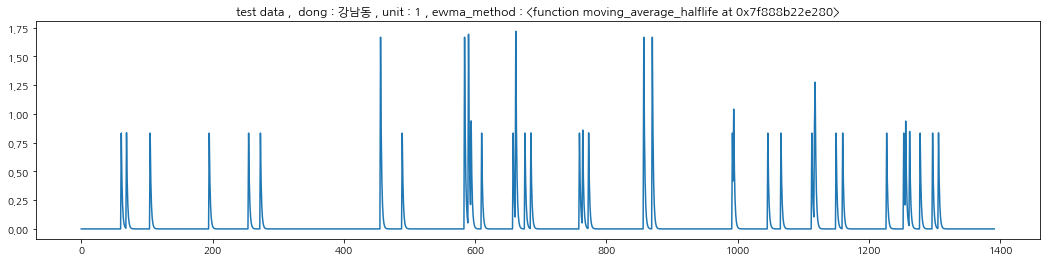

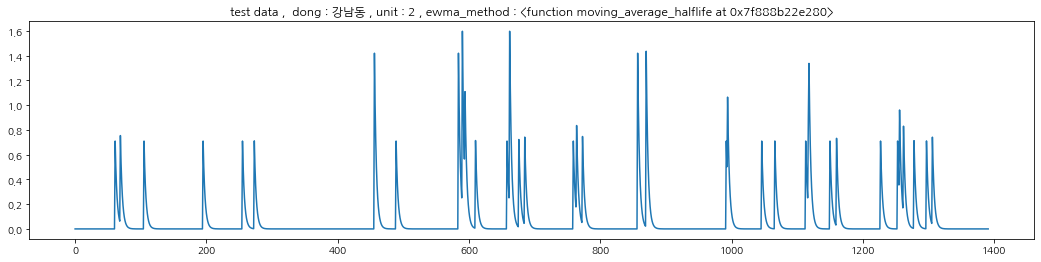

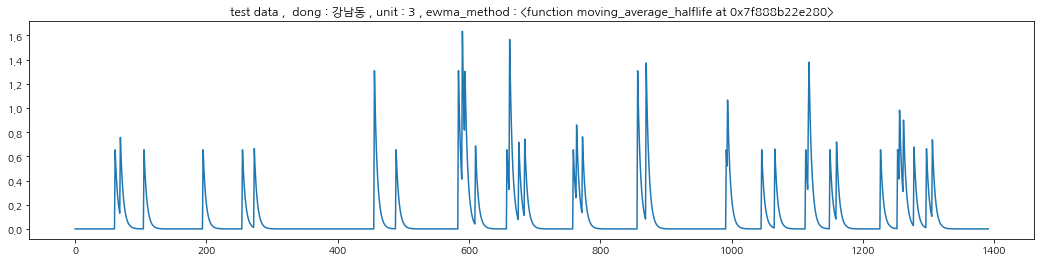

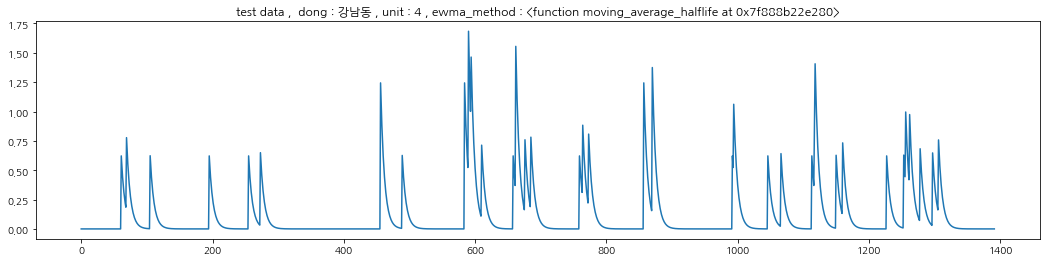

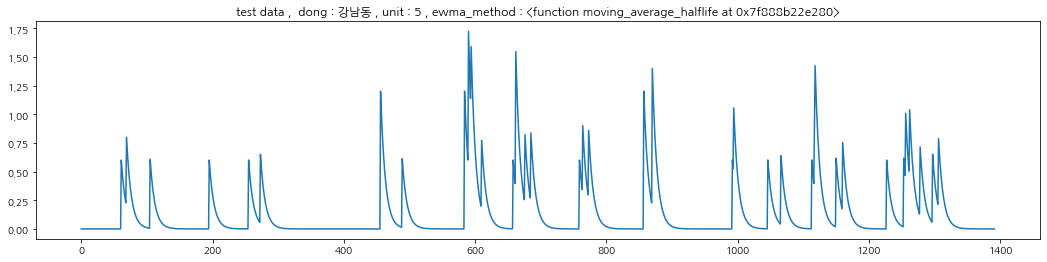

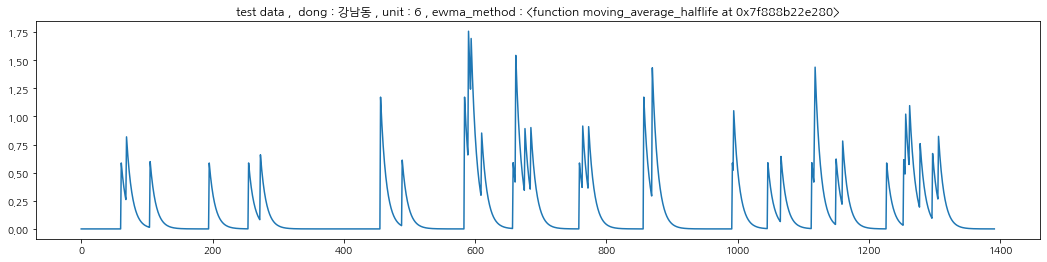

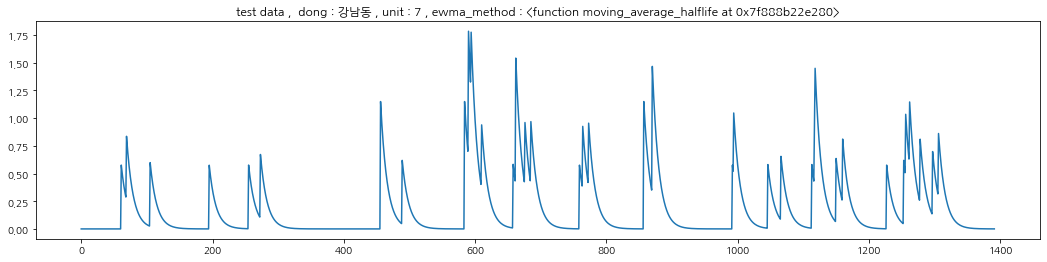

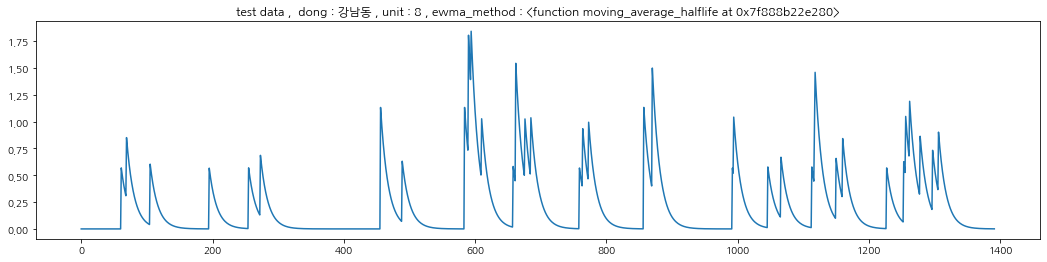

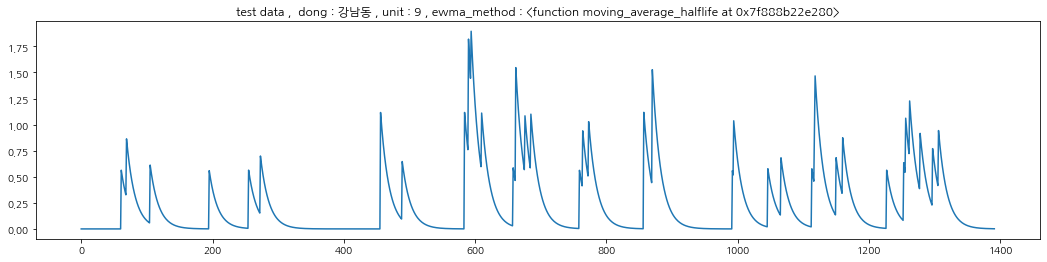

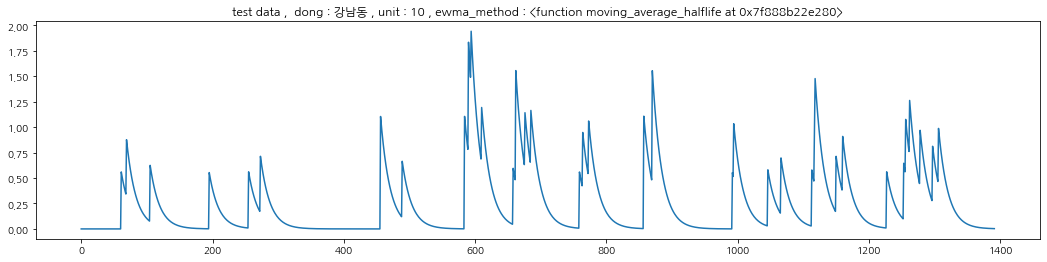

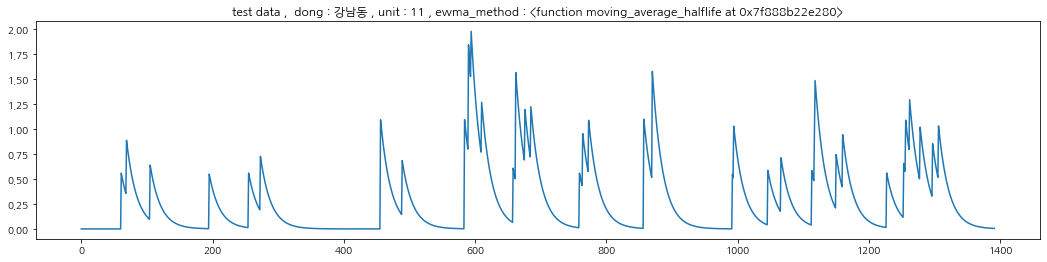

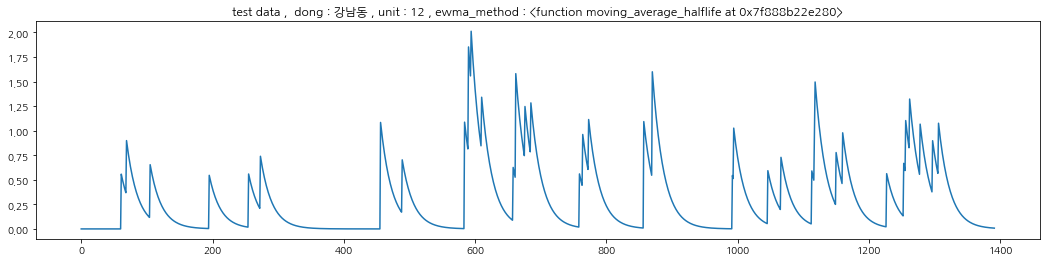

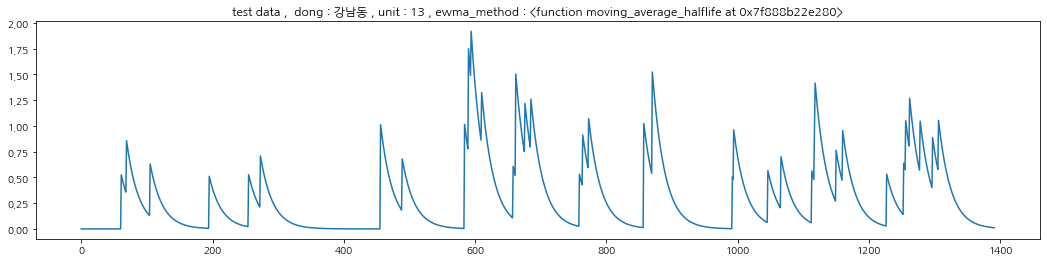

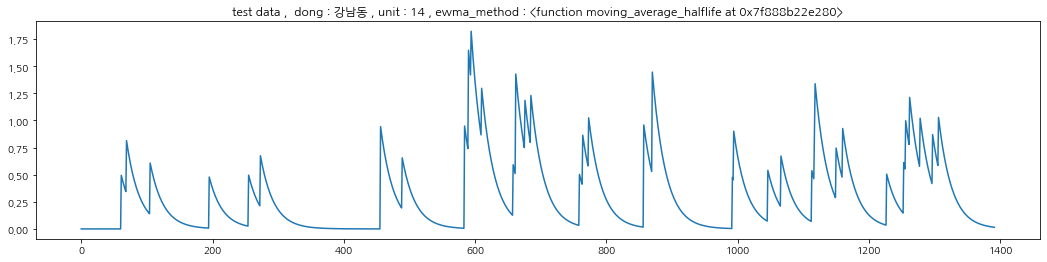

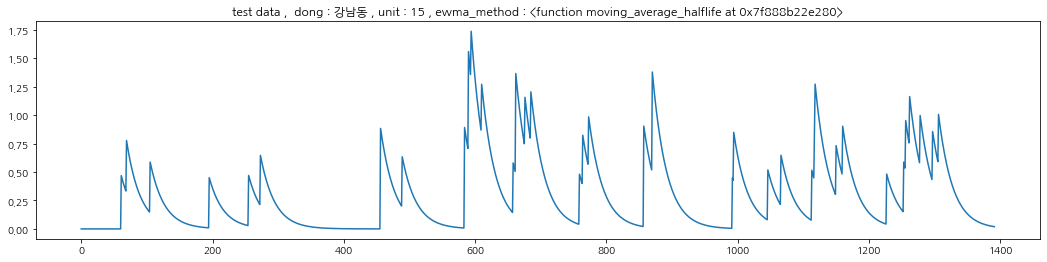

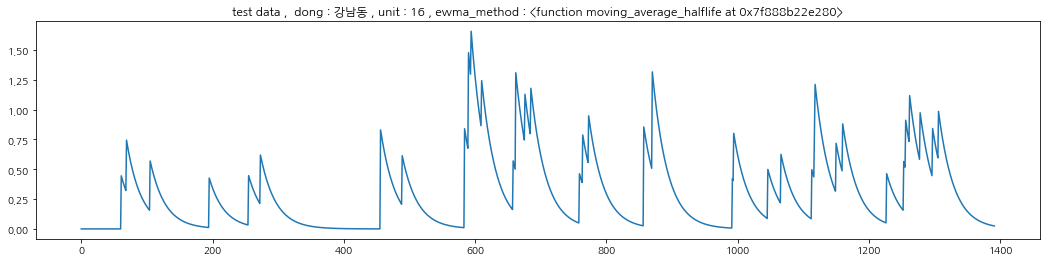

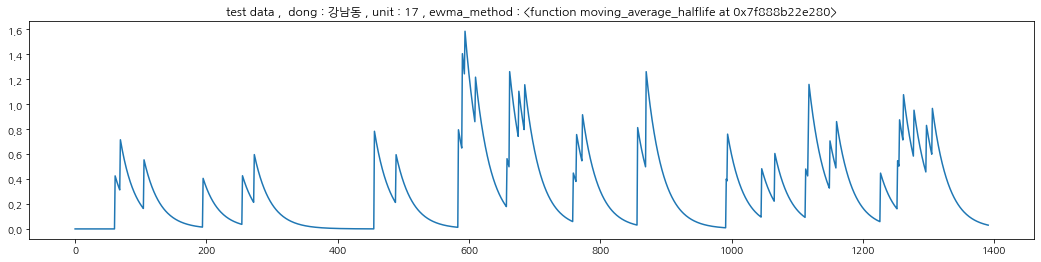

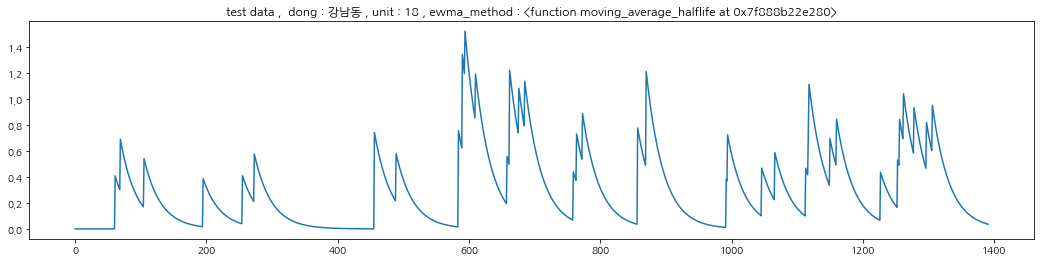

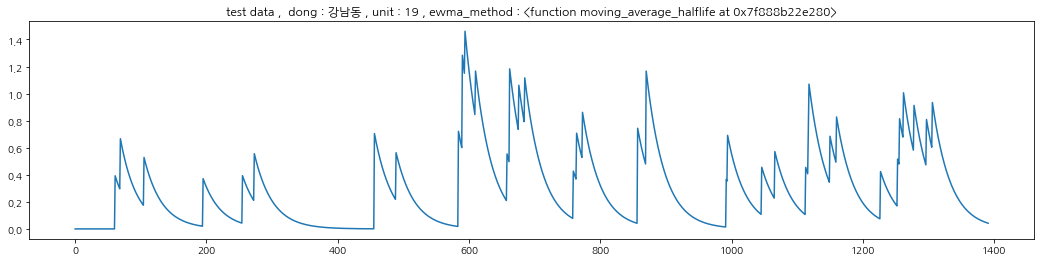

In [85]:
for unit in np.arange(1,20) :
    veiw_ewma('../../test.csv' , unit ,'강남동' , moving_average_halflife)